# TD3 – Exercise 1: Stock prediction with LSTM

Exercise 1: Stock predictionObjective: Build a simple LSTM architecture and apply it to time series prediction.
The aim of the exercise is to build a LSTM-based neural network in order to predict
Facebook stock price evolution. In this example, only past stock prices are used in order
to predict the future price. In reality, many other external information could have been
injected to the network to improve its prediction.
1. Download the FB.csv file from Moodle. Load it as a Pandas dataframe and analyze
it content. If you do not like facebook, you can download another dataset from
yahoo finance.
2. Extract the Open column and convert it into a list.
3. Use a MinMaxScaler to normalize the data between 0.0 and 1.0.
4. Build the dataset:
a. Observations are the prices of the past 60 days (windowed over all the
data)
b. Target is the next day price
At the point, you should have 2 arrays:
- Xs of shape (2086, 60, 1): 2086 samples of 60 stock values
- ys of shape (2086): 2086 target price to predict
5. Split the training dataset in order to keep 80% for training and 20% for testing
6. Build the following sequential model:
a. A LSTM layer of 50 units, returns sequences and dropout of 0.2,
b. A LSTM layer of 50 units, returns sequences and dropout of 0.2,
c. A LSTM layer of 50 units, does not return sequences and dropout of 0.2,
d. A Dense layer with 1 neuron and no activation
7. Compile and train the model with:
a. Adam optimizer
b. Loss function: mean squared error
c. 20 epochs
d. Batch size of 32
8. Plot on the same graph:
a. The normalized dataset
b. The predicted data from training
c. The predicted data from testing

In [6]:
# Import required libraries
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

DATA_DIR = '.'
csv_path = os.path.join(DATA_DIR, 'FB.csv')
print('Using data file:', csv_path)
assert os.path.exists(csv_path), 'FB.csv not found at: ' + csv_path


Using data file: .\FB.csv


In [7]:
# 1. Load FB.csv and inspect the dataframe
df = pd.read_csv(csv_path)

print('Dataframe head:')
display(df.head())
print('\nColumns:', df.columns.tolist())


Dataframe head:


,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400
1,2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700
2,2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600
3,2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000
4,2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200



Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [8]:
# 2. Extract the Open column and convert it into a list / array
open_prices = df['Open'].values.reshape(-1, 1)
print('Number of rows:', len(open_prices))

# 3. Normalize data between 0 and 1 with MinMaxScaler
scaler = MinMaxScaler(feature_range=(0.0, 1.0))
scaled_prices = scaler.fit_transform(open_prices)

# 4. Build the dataset: 60 past days -> next day price
window_size = 60
X, y = [], []
for i in range(window_size, len(scaled_prices)):
    X.append(scaled_prices[i - window_size : i, 0])
    y.append(scaled_prices[i, 0])

X = np.array(X)
y = np.array(y)

# reshape X to (samples, timesteps, features)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print('Shape of X:', X.shape)  # (n_samples, 60, 1)
print('Shape of y:', y.shape)  # (n_samples,)

# 5. Train / test split (80% / 20%), keeping time order
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print('Train samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])


Number of rows: 2146
Shape of X: (2086, 60, 1)
Shape of y: (2086,)
Train samples: 1668
Test samples: 418


In [ ]:
# 6. Build the stacked LSTM model
model = Sequential()

# First LSTM layer, returns sequences
model.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(X_train.shape[1], 1),
))
model.add(Dropout(0.2))

# Second LSTM layer, returns sequences
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Third LSTM layer, does not return sequences
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Final dense layer for regression (1 value, linear activation)
model.add(Dense(1))

model.summary()

# 7. Compile and train
model.compile(optimizer='adam', loss='mean_squared_error')

EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1,
)


c:\Users\Pamit\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0092 - val_loss: 0.0031
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0020 - val_loss: 0.0026
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0019 - val_loss: 0.0056
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0017 - val_loss: 0.0111
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0013 - val_loss: 0.0054
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0013 - val_loss: 0.0038
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0012 - val_loss: 0.0047
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0014 - val_loss: 0.0024
Epoch 9/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0013 - val_loss: 0.0104
Epoch 10/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0013 - val_loss: 0.0033
Epoch 11/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0010 - val_loss: 0.0048
Epoch 12/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0

Predicting on train and test sets...
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


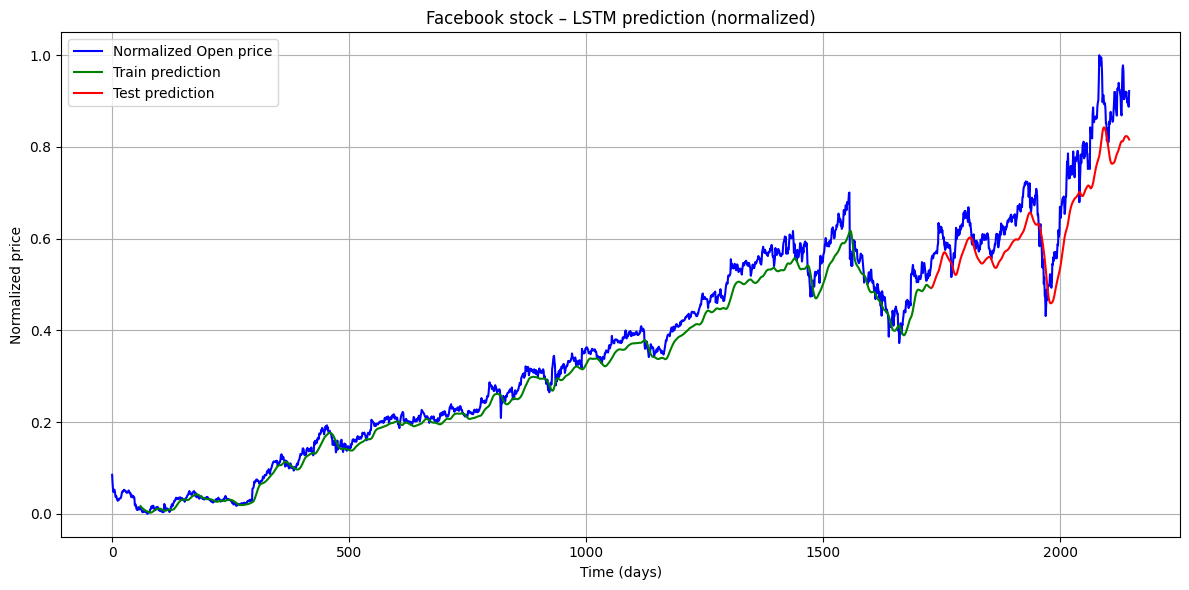

In [10]:
# 8. Make predictions and plot results
print('Predicting on train and test sets...')
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Build series that align with the original scaled prices
pred_train_series = np.full_like(scaled_prices, fill_value=np.nan, dtype=float)
pred_test_series = np.full_like(scaled_prices, fill_value=np.nan, dtype=float)

# windows start at index = window_size in the original series
for i in range(train_size):
    pred_train_series[window_size + i, 0] = train_pred[i, 0]

for i in range(train_size, n_samples):
    j = i - train_size  # index inside test_pred
    pred_test_series[window_size + i, 0] = test_pred[j, 0]

plt.figure(figsize=(12, 6))
plt.plot(scaled_prices, label='Normalized Open price', color='blue')
plt.plot(pred_train_series, label='Train prediction', color='green')
plt.plot(pred_test_series, label='Test prediction', color='red')
plt.title('Facebook stock – LSTM prediction (normalized)')
plt.xlabel('Time (days)')
plt.ylabel('Normalized price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## My Observation

when i run this on the data, the training loss usually goes down over the 20 epochs. it is not a perfectly smooth line but more like a small zig‑zag. on the plot, the green and red prediction curves follow the main trend of the blue real curve, but they look smoother and they miss some of the very sharp jumps.

to me it feels like the model remembers enough of the last 60 days to guess the general direction (up or down), but it cannot guess sudden news or shocks in the market. maybe adding more features (like high, low, volume, or some external news signals) or training for more epochs could help, but then we may overfit and just memorize the training period.

overall i see that the LSTM can capture some temporal pattern in this facebook stock series, but it is still far from a perfect stock price oracle.
